# Chapter 02 Hypothesis Testing: rendered figures

Executed preview for browsing on GitHub (static image output, since GitHub's notebook viewer cannot run the interactive JS the live book uses). The source of truth for regenerating the book's figures is `chapter-02-hypothesis-testing-plots.py`. Run that script directly, not this notebook, to update `_generated/`.

In [1]:
"""
Interactive figures for Chapter 2: Hypothesis Testing.

Same pattern as chapter-01-descriptive-statistics-plots.py: each function builds one
self-contained, standalone Plotly HTML page and writes it to ../_generated/. Run directly
to regenerate every figure:
    python3 chapter-02-hypothesis-testing-plots.py
"""

import os

import numpy as np
import plotly.graph_objects as go
from scipy import stats

RNG = np.random.default_rng(7)
OUT_DIR = os.path.join(os.path.dirname(os.path.abspath(＿_file_＿)), "..", "_generated")
os.makedirs(OUT_DIR, exist_ok=True)


In [2]:
def save(fig: go.Figure, name: str) -> str:
    path = os.path.join(OUT_DIR, f"{name}.html")
    fig.write_html(path, include_plotlyjs="cdn", full_html=True)
    return path


In [3]:


# ---------------------------------------------------------------------------
# Figure 1: t-distribution vs. standard normal as degrees of freedom change
# ---------------------------------------------------------------------------
def fig_t_vs_normal() -> go.Figure:
    x = np.linspace(-5, 5, 400)
    normal_pdf = stats.norm.pdf(x)
    dfs = [1, 2, 5, 10, 30, 100]
    frames = []
    for df in dfs:
        t_pdf = stats.t.pdf(x, df)
        frames.append(
            go.Frame(
                name=str(df),
                data=[
                    go.Scatter(x=x, y=normal_pdf, mode="lines", name="Standard normal",
                               line=dict(color="#4C78A8", width=2, dash="dash")),
                    go.Scatter(x=x, y=t_pdf, mode="lines", name="t-distribution",
                               line=dict(color="#E45756", width=2.5)),
                ],
            )
        )

    fig = go.Figure(data=frames[0].data, frames=frames)
    fig.update_layout(
        title="The t-distribution's tails thin toward the normal as df increases",
        xaxis_title="value",
        yaxis_title="density",
        sliders=[{
            "active": 0,
            "currentvalue": {"prefix": "degrees of freedom: "},
            "steps": [
                {"label": f.name, "method": "animate",
                 "args": [[f.name], {"mode": "immediate", "frame": {"duration": 300}}]}
                for f in frames
            ],
        }],
        margin=dict(t=60, l=60, r=30, b=50),
    )
    return fig


In [4]:


# ---------------------------------------------------------------------------
# Figure 2: Type I vs. Type II error as the significance threshold moves
# ---------------------------------------------------------------------------
def fig_type1_type2() -> go.Figure:
    x = np.linspace(-4, 8, 600)
    null_pdf = stats.norm.pdf(x, loc=0, scale=1)
    alt_pdf = stats.norm.pdf(x, loc=3, scale=1)
    thresholds = [1.0, 1.5, 1.96, 2.5, 3.0]
    frames = []
    for thr in thresholds:
        type1 = 1 - stats.norm.cdf(thr, loc=0, scale=1)
        type2 = stats.norm.cdf(thr, loc=3, scale=1)
        mask1 = x >= thr
        mask2 = x <= thr
        frames.append(
            go.Frame(
                name=f"{thr:.2f}",
                data=[
                    go.Scatter(x=x, y=null_pdf, mode="lines", name="Null (no effect)",
                               line=dict(color="#4C78A8", width=2)),
                    go.Scatter(x=x, y=alt_pdf, mode="lines", name="Alternative (true effect)",
                               line=dict(color="#54A24B", width=2)),
                    go.Scatter(x=x[mask1], y=null_pdf[mask1], fill="tozeroy",
                               mode="none", name="Type I error region",
                               fillcolor="rgba(228,87,86,0.45)"),
                    go.Scatter(x=x[mask2], y=alt_pdf[mask2], fill="tozeroy",
                               mode="none", name="Type II error region",
                               fillcolor="rgba(245,133,24,0.45)"),
                ],
                layout=go.Layout(
                    shapes=[dict(type="line", x0=thr, x1=thr, y0=0, y1=1, yref="paper",
                                 line=dict(color="#333", width=1.5, dash="dot"))],
                    annotations=[dict(
                        x=0.98, y=0.95, xref="paper", yref="paper", showarrow=False,
                        xanchor="right",
                        text=f"Type I (alpha) = {type1:.3f}<br>Type II (beta) = {type2:.3f}",
                        font=dict(size=13, color="#333"),
                    )],
                ),
            )
        )

    fig = go.Figure(data=frames[0].data, frames=frames, layout=frames[0].layout)
    fig.update_layout(
        title="Moving the significance threshold trades Type I error against Type II error",
        xaxis_title="test statistic",
        yaxis_title="density",
        sliders=[{
            "active": 0,
            "currentvalue": {"prefix": "decision threshold: "},
            "steps": [
                {"label": f.name, "method": "animate",
                 "args": [[f.name], {"mode": "immediate", "frame": {"duration": 300}}]}
                for f in frames
            ],
        }],
        margin=dict(t=60, l=60, r=30, b=50),
    )
    return fig


In [5]:


# ---------------------------------------------------------------------------
# Figure 3: statistical power vs. sample size, at a few effect sizes
# ---------------------------------------------------------------------------
def power_two_sample(n: np.ndarray, effect_size: float, alpha: float = 0.05) -> np.ndarray:
    """Normal-approximation power for a two-sample test, illustrative (not a substitute
    for a dedicated power-analysis library on a production sample-size decision)."""
    z_alpha = stats.norm.ppf(1 - alpha / 2)
    ncp = effect_size * np.sqrt(n / 2)
    return (1 - stats.norm.cdf(z_alpha - ncp)) + stats.norm.cdf(-z_alpha - ncp)


In [6]:


def fig_power_curve() -> go.Figure:
    n = np.linspace(5, 500, 200)
    effect_sizes = [0.1, 0.2, 0.3, 0.5, 0.8]
    frames = []
    for d in effect_sizes:
        power = power_two_sample(n, d)
        frames.append(
            go.Frame(
                name=f"{d:.1f}",
                data=[go.Scatter(x=n, y=power, mode="lines", line=dict(color="#4C78A8", width=3))],
                layout=go.Layout(shapes=[dict(
                    type="line", x0=0, x1=1, xref="paper", y0=0.8, y1=0.8,
                    line=dict(color="#E45756", width=1.5, dash="dash"),
                )]),
            )
        )

    fig = go.Figure(data=frames[0].data, frames=frames, layout=frames[0].layout)
    fig.update_layout(
        title="Statistical power rises with sample size, more slowly for smaller effects",
        xaxis_title="sample size per group (n)",
        yaxis_title="power",
        yaxis_range=[0, 1],
        sliders=[{
            "active": 0,
            "currentvalue": {"prefix": "effect size (Cohen's d): "},
            "steps": [
                {"label": f.name, "method": "animate",
                 "args": [[f.name], {"mode": "immediate", "frame": {"duration": 300}}]}
                for f in frames
            ],
        }],
        margin=dict(t=60, l=60, r=30, b=50),
    )
    return fig


In [7]:


# ---------------------------------------------------------------------------
# Figure 4: t-test vs. Wilcoxon rank-sum as outliers contaminate skewed data
# ---------------------------------------------------------------------------
def fig_parametric_vs_nonparametric() -> go.Figure:
    n = 200
    base_control = RNG.lognormal(mean=np.log(45), sigma=0.35, size=n)
    base_treatment = RNG.lognormal(mean=np.log(40), sigma=0.35, size=n)
    contaminations = [0, 1, 2, 3, 5]
    frames = []
    for k in contaminations:
        control = base_control.copy()
        treatment = base_treatment.copy()
        if k:
            idx = RNG.choice(n, size=k, replace=False)
            control[idx] = RNG.lognormal(mean=np.log(600), sigma=0.3, size=k)
        t_stat, t_p = stats.ttest_ind(control, treatment, equal_var=False)
        w_stat, w_p = stats.mannwhitneyu(control, treatment, alternative="two-sided")
        hist_c = np.histogram(control, bins=np.linspace(0, 800, 60))
        hist_t = np.histogram(treatment, bins=np.linspace(0, 800, 60))
        frames.append(
            go.Frame(
                name=str(k),
                data=[
                    go.Bar(x=hist_c[1][:-1], y=hist_c[0], name="Control", opacity=0.6,
                           marker_color="#4C78A8"),
                    go.Bar(x=hist_t[1][:-1], y=hist_t[0], name="Treatment", opacity=0.6,
                           marker_color="#54A24B"),
                ],
                layout=go.Layout(annotations=[dict(
                    x=0.98, y=0.95, xref="paper", yref="paper", showarrow=False,
                    xanchor="right",
                    text=f"t-test p = {t_p:.4f}<br>Wilcoxon rank-sum p = {w_p:.4f}",
                    font=dict(size=13, color="#333"),
                )]),
            )
        )

    fig = go.Figure(data=frames[0].data, frames=frames, layout=frames[0].layout)
    fig.update_layout(
        barmode="overlay",
        title="A t-test's p-value moves more than a Wilcoxon rank-sum test's as outliers "
              "are added",
        xaxis_title="latency (ms)",
        yaxis_title="count",
        xaxis_range=[0, 800],
        sliders=[{
            "active": 0,
            "currentvalue": {"prefix": "outlier requests added to control: "},
            "steps": [
                {"label": f.name, "method": "animate",
                 "args": [[f.name], {"mode": "immediate", "frame": {"duration": 300}}]}
                for f in frames
            ],
        }],
        margin=dict(t=60, l=60, r=30, b=50),
    )
    return fig


In [8]:


# ---------------------------------------------------------------------------
# Figure 5: ANOVA, between-group vs. within-group variance across three regions
# ---------------------------------------------------------------------------
def fig_anova_between_within() -> go.Figure:
    n_per_group = 60
    within_sigma = 12.0
    base_means = [45.0, 45.0, 45.0]
    gaps = [0.0, 3.0, 8.0, 15.0, 25.0]
    frames = []
    for gap in gaps:
        means = [base_means[0] - gap / 2, base_means[1], base_means[2] + gap / 2]
        groups = [RNG.normal(loc=m, scale=within_sigma, size=n_per_group) for m in means]
        f_stat, p_val = stats.f_oneway(*groups)
        frames.append(
            go.Frame(
                name=f"{gap:.0f}",
                data=[
                    go.Box(y=groups[0], name="Region A", marker_color="#4C78A8",
                           boxpoints="all", jitter=0.4, pointpos=0),
                    go.Box(y=groups[1], name="Region B", marker_color="#54A24B",
                           boxpoints="all", jitter=0.4, pointpos=0),
                    go.Box(y=groups[2], name="Region C", marker_color="#F58518",
                           boxpoints="all", jitter=0.4, pointpos=0),
                ],
                layout=go.Layout(annotations=[dict(
                    x=0.02, y=0.97, xref="paper", yref="paper", showarrow=False,
                    xanchor="left",
                    text=f"F = {f_stat:.2f}<br>p = {p_val:.4f}",
                    font=dict(size=13, color="#333"),
                )]),
            )
        )

    fig = go.Figure(data=frames[0].data, frames=frames, layout=frames[0].layout)
    fig.update_layout(
        title="ANOVA: as the gap between region means grows, F rises and p falls",
        yaxis_title="Latency (ms)",
        showlegend=False,
        sliders=[{
            "active": 0,
            "currentvalue": {"prefix": "Gap between region means (ms): "},
            "steps": [
                {"label": f.name, "method": "animate",
                 "args": [[f.name], {"mode": "immediate", "frame": {"duration": 300}}]}
                for f in frames
            ],
        }],
        margin=dict(t=60, l=60, r=30, b=50),
    )
    return fig


In [9]:


FIGURES = {
    "chapter-02-fig-t-vs-normal": fig_t_vs_normal,
    "chapter-02-fig-type1-type2": fig_type1_type2,
    "chapter-02-fig-power-curve": fig_power_curve,
    "chapter-02-fig-parametric-vs-nonparametric": fig_parametric_vs_nonparametric,
    "chapter-02-fig-anova-between-within": fig_anova_between_within,
}


**`chapter-02-fig-t-vs-normal`**

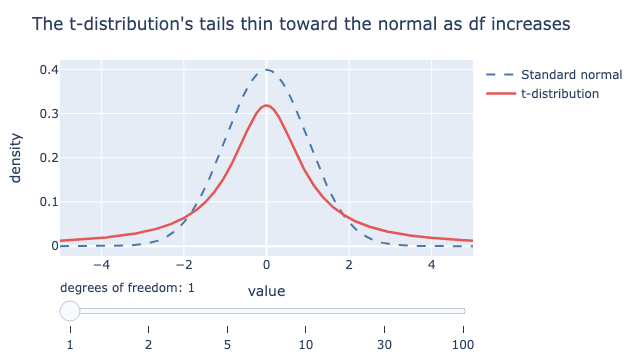

In [10]:
fig = FIGURES["chapter-02-fig-t-vs-normal"]()
fig

**`chapter-02-fig-type1-type2`**

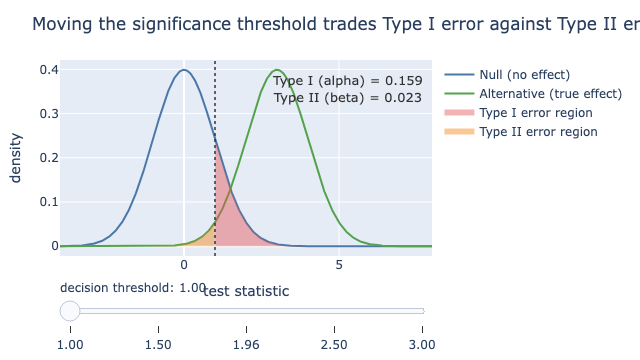

In [11]:
fig = FIGURES["chapter-02-fig-type1-type2"]()
fig

**`chapter-02-fig-power-curve`**

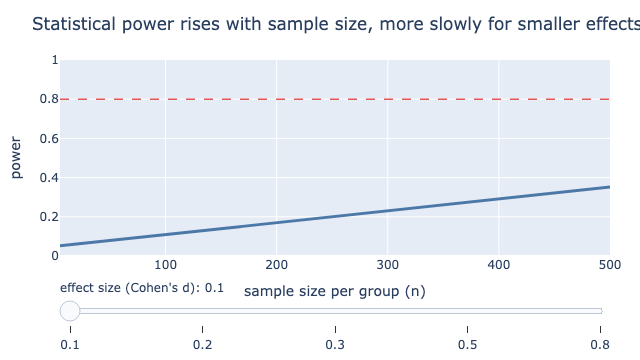

In [12]:
fig = FIGURES["chapter-02-fig-power-curve"]()
fig

**`chapter-02-fig-parametric-vs-nonparametric`**

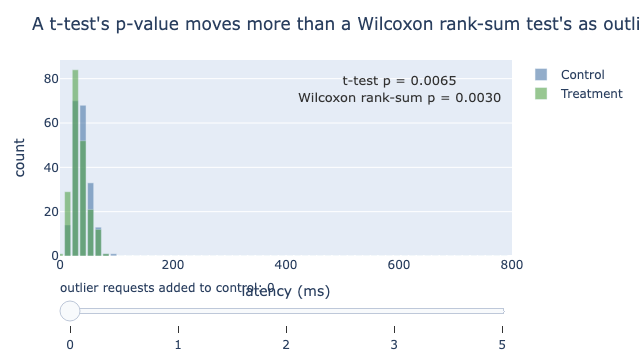

In [13]:
fig = FIGURES["chapter-02-fig-parametric-vs-nonparametric"]()
fig

**`chapter-02-fig-anova-between-within`**

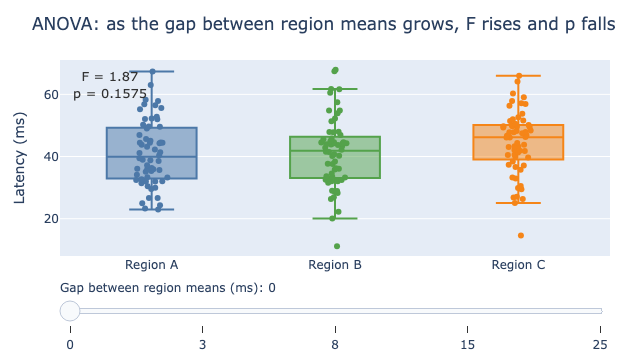

In [14]:
fig = FIGURES["chapter-02-fig-anova-between-within"]()
fig